In [1]:
import os
import tensorflow as tf

# Tắt log rác, chỉ hiện lỗi quan trọng
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Cấu hình GPU để không chiếm hết VRAM ngay lập tức
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ Đã cấu hình Memory Growth cho: {len(gpus)} GPU")
    except RuntimeError as e:
        print(e)

✅ Đã cấu hình Memory Growth cho: 1 GPU


In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Cấu hình đường dẫn (Trỏ đúng vào folder bạn đã save ở bước tiền xử lý)
DATA_DIR = r"C:\Users\ADMIN\Documents\DANG_KHOA\processed_data_tiny"

# Hàm load dữ liệu
def load_data(data_dir):
    print("Đang load dữ liệu từ Drive...")
    X_train = np.load(os.path.join(data_dir, 'X_train.npy'))
    y_train = np.load(os.path.join(data_dir, 'y_train.npy'))

    X_val = np.load(os.path.join(data_dir, 'X_val.npy'))
    y_val = np.load(os.path.join(data_dir, 'y_val.npy'))

    X_test = np.load(os.path.join(data_dir, 'X_test.npy'))
    y_test = np.load(os.path.join(data_dir, 'y_test.npy'))

    print(f"Train shape: {X_train.shape} | Labels: {y_train.shape}")
    print(f"Val shape:   {X_val.shape}   | Labels: {y_val.shape}")
    print(f"Test shape:  {X_test.shape}  | Labels: {y_test.shape}")

    return X_train, y_train, X_val, y_val, X_test, y_test

X_train, y_train, X_val, y_val, X_test, y_test = load_data(DATA_DIR)

Đang load dữ liệu từ Drive...
Train shape: (240757, 2500, 1) | Labels: (240757,)
Val shape:   (32678, 2500, 1)   | Labels: (32678,)
Test shape:  (62205, 2500, 1)  | Labels: (62205,)


In [3]:
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

# =============================================================================
# 0. THIẾT LẬP REPRODUCIBILITY (Đã khôi phục)
# =============================================================================
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
# os.environ['TF_DETERMINISTIC_OPS'] = '1'

def learnable_downsample(x, filters, block_name):
    """
    Kỹ thuật Strided Convolution thay thế MaxPooling (theo Bui An Dong [2] và Squeeze U-Net [4]).
    - Kernel=3: Đảm bảo "nhìn" thấy thông tin của 3 mẫu liền kề, tránh mất dữ liệu.
    - Stride=2: Giảm kích thước tín hiệu đi một nửa (Downsampling).
    - Learnable: Có trọng số để mạng tự học cách nén dữ liệu tối ưu nhất.
    """
    x = layers.Conv1D(
        filters=filters,
        kernel_size=3,        # Kernel > 1 là bắt buộc khi stride > 1
        strides=2,            # Thực hiện giảm mẫu tại đây
        padding='same',
        use_bias=False,
        kernel_regularizer=regularizers.l2(L2_RATE),
        name=f'{block_name}_downsample'
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    return x

# =============================================================================
# 1. CẤU HÌNH & DATA AUGMENTATION (Đã khôi phục đầy đủ)
# =============================================================================
L2_RATE = 1e-3
INPUT_SHAPE = (2500, 1)

def get_augmentation_layer():
    return tf.keras.Sequential([
        layers.GaussianNoise(0.05),
        layers.Lambda(lambda x: x * tf.random.uniform(tf.shape(x), 0.8, 1.2)),
        layers.Lambda(lambda x: x + tf.random.uniform(tf.shape(x), -0.1, 0.1)),  # dấu phẩy
        layers.Lambda(lambda x: x + 0.1 * tf.math.sin(
            tf.linspace(0.0, 2.0 * 3.14, tf.shape(x)[1]) * tf.random.uniform([], 0.5, 2.0)
        )[tf.newaxis, :, tf.newaxis]),  # sửa chiều broadcasting
        layers.Dropout(0.1)
    ], name="Augmentation_Block")


# =============================================================================
# 2: SE BLOCK (BỔ SUNG PHẦN THIẾU)
# =============================================================================
def se_block(x, filters, ratio=4):
    se = layers.GlobalAveragePooling1D()(x)
    se = layers.Dense(filters // ratio, use_bias=False, kernel_regularizer=regularizers.l2(L2_RATE))(se)
    se = layers.LeakyReLU(alpha=0.1)(se)
    se = layers.Dense(filters, activation='sigmoid', use_bias=False, kernel_regularizer=regularizers.l2(L2_RATE))(se)
    se = layers.Reshape((1, filters))(se)
    x = layers.Multiply()([x, se])
    return x
    
# =============================================================================
# 3. DILATED FIRE MODULE (ĐÃ SỬA LỖI XUNG ĐỘT STRIDE/DILATION)
# =============================================================================
def dilated_fire_module(x, squeeze_filters, expand_filters, dilation_rate, block_name):

    s_id = f'fire_{block_name}_squeeze'
    e_id = f'fire_{block_name}_expand'

    # --- INPUT SAVE FOR RESIDUAL ---
    shortcut = x

    # --- 1. SQUEEZE LAYER ---
    
    squeezed = layers.Conv1D(
        filters=squeeze_filters,
        kernel_size=1,

        padding='same',
        strides=1,
        kernel_regularizer=regularizers.l2(L2_RATE),
        use_bias=False,
        name=s_id
    )(x)
    squeezed = layers.BatchNormalization()(squeezed)
    squeezed = layers.LeakyReLU(alpha=0.1)(squeezed) # <--- THÊM VÀO ĐÂY

    # --- 2. EXPAND LAYER ---
    
    # Nhánh 1x1
    expand1x1 = layers.Conv1D(
        filters=expand_filters,
        kernel_size=1,
        
        padding='same',
        strides=1,          
        kernel_regularizer=regularizers.l2(L2_RATE),
        use_bias=False,
        name=f'{e_id}_1x1'
    )(squeezed)
    expand1x1 = layers.LeakyReLU(alpha=0.1)(expand1x1) # <--- THÊM VÀO ĐÂY

    # Nhánh 3x3 (Có Dilation)
    # Vì stride=1 nên kết hợp được với dilation_rate > 1
    expand3x3 = layers.Conv1D(
        filters=expand_filters,
        kernel_size=3,

        padding='same',
        strides=1,           
        dilation_rate=dilation_rate,
        kernel_regularizer=regularizers.l2(L2_RATE),
        use_bias=False,
        name=f'{e_id}_3x3_dil{dilation_rate}'
    )(squeezed)
    expand3x3 = layers.LeakyReLU(alpha=0.1)(expand3x3) # <--- THÊM VÀO ĐÂY

    # Ghép nối
    main_out = layers.Concatenate(axis=-1)([expand1x1, expand3x3])
    main_out = layers.BatchNormalization()(main_out)

    # SE BLOCK
    current_filters = expand_filters * 2
    main_out = se_block(main_out, current_filters, ratio=4)

    # --- 3. RESIDUAL CONNECTION ---
    # Kiểm tra khớp kích thước channels để cộng
    if x.shape[-1] == main_out.shape[-1]:
        # Cộng trực tiếp nếu khớp
        x = layers.Add(name=f'fire_{block_name}_add')([main_out, x])
    else:
        # Chiếu (Projection) nếu lệch kênh (dùng kernel 1x1, stride 1)
        shortcut = layers.Conv1D(
            filters=main_out.shape[-1],
            kernel_size=1,
            strides=1,
            padding='same',
            use_bias=False,
            name=f'fire_{block_name}_sc_proj'
        )(x)
        shortcut = layers.BatchNormalization()(shortcut)
        x = layers.Add(name=f'fire_{block_name}_add')([main_out, shortcut])

    x = layers.LeakyReLU(alpha=0.1)(x) # <--- THAY BẰNG DÒNG MỚI
    x = layers.SpatialDropout1D(0.4)(x)

    return x

# =============================================================================
# 4. MÔ HÌNH CHÍNH
# =============================================================================
def build_dilated_se_firenet(input_shape=INPUT_SHAPE):
    inputs = layers.Input(shape=input_shape, name="Input_ECG")

    # Augmentation
    x = get_augmentation_layer()(inputs)

    # --- STEM BLOCK ---
    # Giữ stride=2 để giảm mẫu ngay từ đầu
    x = layers.Conv1D(32, 7, strides=2, padding='same',
                      kernel_regularizer=regularizers.l2(L2_RATE),
                      use_bias=False, name="Stem_Conv")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x) # <--- THAY BẰNG DÒNG MỚI

    # --- BLOCK 1: Dilation=1 ---
    x = dilated_fire_module(x, squeeze_filters=16, expand_filters=16,
                            dilation_rate=1, block_name="block1")
    x = learnable_downsample(x, filters=48, block_name="down1")

    # --- BLOCK 2: Dilation=2 ---
    x = dilated_fire_module(x, squeeze_filters=24, expand_filters=24,
                            dilation_rate=2, block_name="block2")
    x = learnable_downsample(x, filters=64, block_name="down2")

    # --- BLOCK 3: Dilation=4 ---
    x = dilated_fire_module(x, squeeze_filters=32, expand_filters=32,
                            dilation_rate=4, block_name="block3")
    x = learnable_downsample(x, filters=96, block_name="down3")

    # --- BLOCK 4: Dilation=8 (Deep Feature) ---
    x = dilated_fire_module(x, squeeze_filters=48, expand_filters=48,
                            dilation_rate=8, block_name="block4")

    # Classifier
    # x = layers.GlobalAveragePooling1D(name="Global_Avg_Pool")(x)
    gap = layers.GlobalAveragePooling1D(name="Global_Avg_Pool")(x) # Thêm cái này
    gmp = layers.GlobalMaxPooling1D(name="Global_Max_Pool")(x) # Thêm cái này
    x = layers.Concatenate()([gap, gmp]) # Thêm cái này
    
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(2, activation='softmax', dtype='float32', name="Output_Prob")(x)

    return models.Model(inputs=inputs, outputs=outputs, name="Dilated_SE_FireNet_Compact")

# Kiểm tra lại số lượng tham số
model = build_dilated_se_firenet()
model.summary()

Model: "Dilated_SE_FireNet_Compact"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 Input_ECG (InputLayer)         [(None, 2500, 1)]    0           []                               
                                                                                                  
 Augmentation_Block (Sequential  (None, 2500, 1)     0           ['Input_ECG[0][0]']              
 )                                                                                                
                                                                                                  
 Stem_Conv (Conv1D)             (None, 1250, 32)     224         ['Augmentation_Block[0][0]']     
                                                                                                  
 batch_normalization (BatchNorm  (None, 1250, 32)    128         ['Stem_C

In [4]:
from sklearn.metrics import classification_report, accuracy_score, f1_score
import pandas as pd
from sklearn.utils import class_weight
import tensorflow as tf
import tensorflow.keras.backend as K

# =============================================================================
# 4. CHUẨN BỊ VÀ HUẤN LUYỆN
# =============================================================================

'''
def categorical_focal_loss(gamma=2.0):
    """
    Focal Loss theo chuẩn nghiên cứu của Petmezas et al. (2021) cho ECG.
    - gamma=2.0: Giúp model tập trung vào các mẫu khó (AFIB).
    - Không dùng alpha: Để tránh xung đột với class_weight trong model.fit().
    """
    def focal_loss_fixed(y_true, y_pred):
        # 1. Clip giá trị để tránh log(0) gây lỗi NaN
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1.0 - epsilon)

        # 2. Tính Cross Entropy cơ bản
        cross_entropy = -y_true * K.log(y_pred)

        # 3. Tính hệ số Focusing (1 - p)^gamma
        # Mẫu nào model càng tự tin (p cao) thì loss càng bị giảm đi
        weight = K.pow((1 - y_pred), gamma)

        # 4. Tổng hợp
        loss = weight * cross_entropy
        
        # 5. Tính tổng loss
        return K.sum(loss, axis=1)

    return focal_loss_fixed
'''

'''
# A. One-hot encoding
y_train_onehot = tf.keras.utils.to_categorical(y_train, num_classes=2)
y_val_onehot   = tf.keras.utils.to_categorical(y_val, num_classes=2)

# B. Class Weights (Giữ nguyên chiến thuật đã thành công)
y_integers = np.argmax(y_train_onehot, axis=1)
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_integers),
    y=y_integers
)
class_weight_dict = dict(enumerate(class_weights))

print(f"⚖️ Trọng số lớp (Fixed Seed): {class_weight_dict}")
'''

model = build_dilated_se_firenet()

# 1. Label Smoothing Loss: Chìa khóa chống Loss nhảy
# Thay vì phạt lỗi dựa trên nhãn cứng (0, 1), ta dùng nhãn mềm (0.05, 0.95)
# Lưu ý: Khi dùng Label Smoothing, ta cần dùng Categorical Crossentropy (One-hot)
# thay vì Sparse. Vì Sparse không hỗ trợ smoothing trực tiếp trong một số bản TF cũ.
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

# 2. Chuyển đổi nhãn sang One-hot (Bắt buộc cho Label Smoothing)
y_train_onehot = tf.keras.utils.to_categorical(y_train, num_classes=2)
y_val_onehot   = tf.keras.utils.to_categorical(y_val, num_classes=2)

# 3. Optimizer với Cosine Decay (Giảm LR mượt mà)
# Tổng step = (240757 / 128) * 60 epochs ~= 112,800 steps
initial_lr = 1e-4
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=initial_lr,
    decay_steps=112800, # Ước lượng số steps cho 60 epochs
    alpha=0.01          # LR cuối cùng = 1% LR ban đầu
)

# C. Optimizer & Callbacks
# optimizer = optimizers.Adam(learning_rate=0.0001)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

# --- THÊM CÁC METRICS QUAN TRỌNG CHO Y SINH ---

'''
metrics_list = [
    'accuracy',
    tf.keras.metrics.AUC(name='auc'),          # Quan trọng nhất
    tf.keras.metrics.Recall(name='sensitivity'), # Độ nhạy (Quan trọng nhì: Không bỏ sót bệnh)
    tf.keras.metrics.Precision(name='precision') # Độ chính xác (Tránh báo động giả)
]
'''

metrics_list = ['accuracy', tf.keras.metrics.AUC(name='auc')]

model.compile(
    optimizer=optimizer,
    # loss=categorical_focal_loss(gamma=2.0),
    loss = loss_fn,
    metrics=metrics_list
)

callbacks_list = [
    # Chỉ lưu model tốt nhất
    callbacks.ModelCheckpoint('best_robust_model_final.keras', monitor='val_loss', save_best_only=True, verbose=1),
    # Dừng sớm nếu không cải thiện trong 15 epochs
    callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
]

print(f"🚀 Bắt đầu huấn luyện (Seed={SEED})...")

'''
history = model.fit(
    X_train, y_train_onehot,
    validation_data=(X_val, y_val_onehot),
    epochs=60,
    batch_size=128,
    callbacks=callbacks_list,
    class_weight=class_weight_dict,
    shuffle=True # Shuffle này cũng sẽ được cố định bởi np.random.seed
)
'''

history = model.fit(
    X_train, y_train_onehot, # Dùng One-hot
    validation_data=(X_val, y_val_onehot),
    epochs=60,
    batch_size=128,
    callbacks=callbacks_list,
    shuffle=True,
    verbose=1
)

🚀 Bắt đầu huấn luyện (Seed=42)...
Epoch 1/60
1881/1881 [==============================] - ETA: 0s - loss: 2.0456 - accuracy: 0.5512 - auc: 0.5621
Epoch 1: val_loss improved from inf to 1.27654, saving model to best_robust_model_final.keras
1881/1881 [==============================] - 284s 50ms/step - loss: 2.0456 - accuracy: 0.5512 - auc: 0.5621 - val_loss: 1.2765 - val_accuracy: 0.7977 - val_auc: 0.8916
Epoch 2/60
1880/1881 [============================>.] - ETA: 0s - loss: 1.1449 - accuracy: 0.7377 - auc: 0.8251
Epoch 2: val_loss improved from 1.27654 to 0.92831, saving model to best_robust_model_final.keras
1881/1881 [==============================] - 94s 50ms/step - loss: 1.1449 - accuracy: 0.7378 - auc: 0.8251 - val_loss: 0.9283 - val_accuracy: 0.8925 - val_auc: 0.9656
Epoch 3/60
1880/1881 [============================>.] - ETA: 0s - loss: 0.8269 - accuracy: 0.8930 - auc: 0.9605
Epoch 3: val_loss improved from 0.92831 to 0.70360, saving model to best_robust_model_final.keras
1881/

Đang dự đoán trên tập Test...
1944/1944 [==============================] - 7s 3ms/step

--- BÁO CÁO KẾT QUẢ TRÊN TẬP TEST ---

Thời gian dự đoán toàn bộ tập test: 7.4074 giây
Thời gian trung bình mỗi mẫu: 0.1191 ms

              precision    recall  f1-score   support

  Normal (0)     1.0000    0.8914    0.9426     33990
    AFib (1)     0.8843    1.0000    0.9386     28215

    accuracy                         0.9406     62205
   macro avg     0.9421    0.9457    0.9406     62205
weighted avg     0.9475    0.9406    0.9408     62205



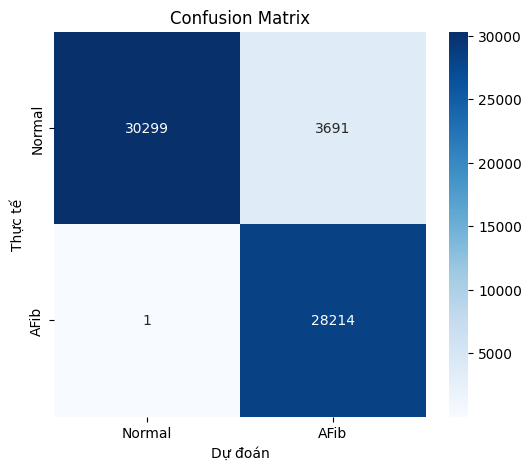

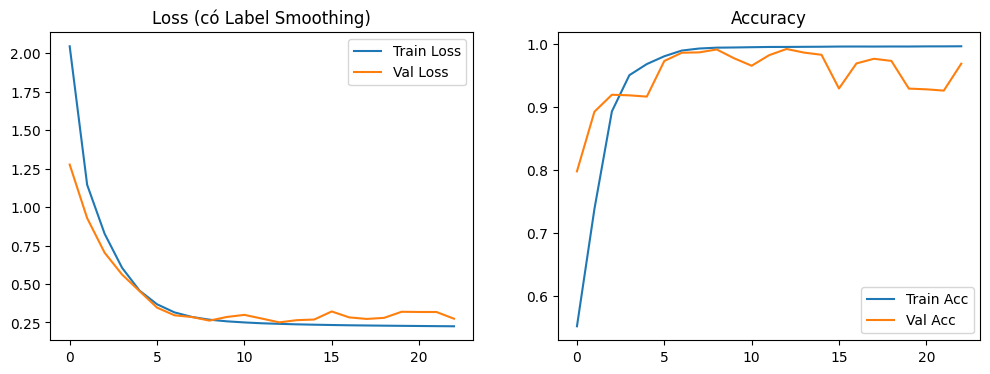

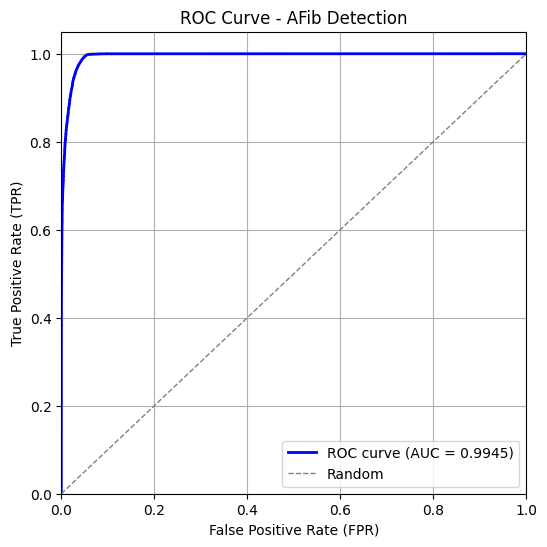

In [5]:
from sklearn.metrics import f1_score, precision_score, recall_score, roc_curve, auc
import time

# =============================================================================
# BƯỚC 5: ĐÁNH GIÁ (UPDATED)
# =============================================================================

final_model = model

print("Đang dự đoán trên tập Test...")
# Lưu ý: Model dự đoán ra xác suất [p0, p1]
start_time = time.perf_counter()
y_pred_probs = final_model.predict(X_test)
end_time = time.perf_counter()


inference_time = end_time - start_time
time_per_sample = inference_time / len(X_test)
# Lấy vị trí có xác suất lớn nhất -> Ra nhãn 0 hoặc 1
y_pred = np.argmax(y_pred_probs, axis=1)

# --- BÁO CÁO ---
print("\n--- BÁO CÁO KẾT QUẢ TRÊN TẬP TEST ---")
print(f"\nThời gian dự đoán toàn bộ tập test: {inference_time:.4f} giây")
print(f"Thời gian trung bình mỗi mẫu: {time_per_sample*1000:.4f} ms\n")

# y_test của bạn vẫn là số nguyên (0, 1) nên so sánh trực tiếp được
print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'AFib (1)'], digits=4))


# --- CONFUSION MATRIX ---
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'AFib'], yticklabels=['Normal', 'AFib'])
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.title('Confusion Matrix')
plt.show()

# --- BIỂU ĐỒ LOSS & ACCURACY ---
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss (có Label Smoothing)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

# --- ROC CURVE ---
y_pred_prob_afib = y_pred_probs[:, 1]  # xác suất lớp 1
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_afib)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve - AFib Detection')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

plt.show()

⏳ Đang dự đoán xác suất...

🔍 KẾT QUẢ TỐI ƯU HÓA TRÊN TẬP VAL:
   - Ngưỡng tối ưu (Best Threshold): 0.5305
   - Tại ngưỡng này trên Val: Sensitivity=0.9914, Specificity=0.9937

==================== BÁO CÁO KẾT QUẢ CUỐI CÙNG (TẬP TEST) ====================
Áp dụng ngưỡng decision threshold = 0.5305
              precision    recall  f1-score   support

  Normal (0)     0.9999    0.8962    0.9452     33990
    AFib (1)     0.8888    0.9999    0.9411     28215

    accuracy                         0.9432     62205
   macro avg     0.9444    0.9480    0.9432     62205
weighted avg     0.9495    0.9432    0.9434     62205



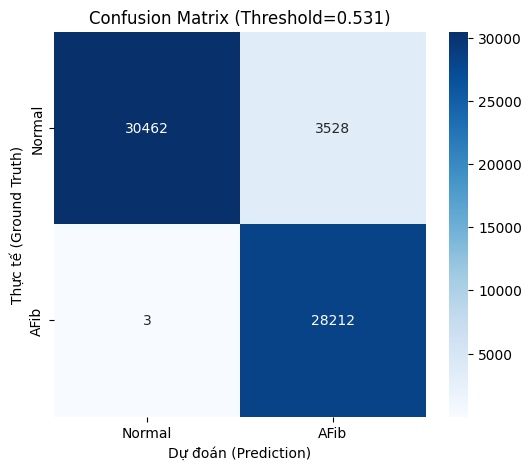

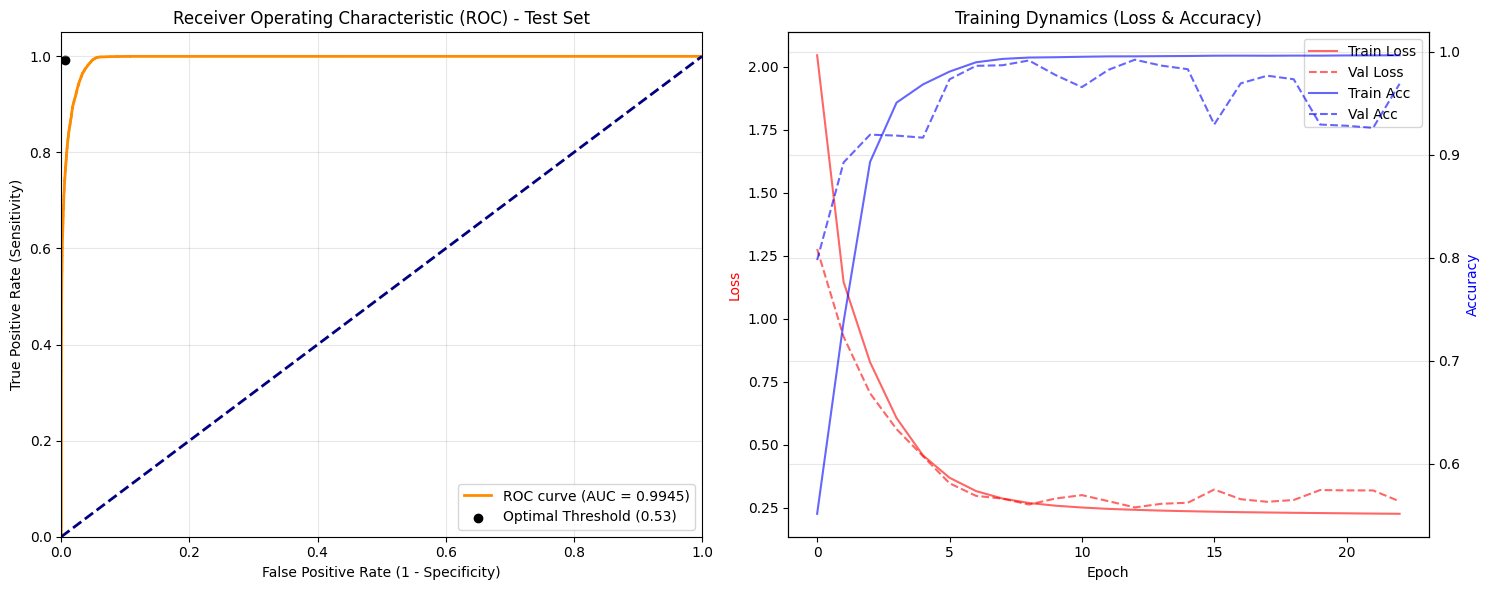

In [6]:
# =============================================================================
# BƯỚC 5: ĐÁNH GIÁ TOÀN DIỆN & TỐI ƯU NGƯỠNG (SCIENTIFIC REPORT)
# =============================================================================
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Dự đoán xác suất trên tập VAL và TEST
print("⏳ Đang dự đoán xác suất...")
# Lấy xác suất lớp 1 (Rung nhĩ)
y_val_probs = model.predict(X_val, verbose=0)[:, 1]
y_test_probs = model.predict(X_test, verbose=0)[:, 1]

# =============================================================================
# A. TÌM NGƯỠNG TỐI ƯU TRÊN TẬP VAL (Threshold Tuning)
# =============================================================================
# Mục tiêu: Giữ Sensitivity (Recall AFIB) > 99% nhưng tăng Precision/Specificity
fpr, tpr, thresholds = roc_curve(y_val, y_val_probs)

# Tìm ngưỡng sao cho Sensitivity >= 0.99
optimal_idx = np.argmax(tpr >= 0.99) 
# Tuy nhiên, để an toàn và giảm báo động giả, ta thường dùng Youden's J statistic
# J = Sensitivity + Specificity - 1
J = tpr - fpr
ix = np.argmax(J)
best_thresh = thresholds[ix]

print(f"\n🔍 KẾT QUẢ TỐI ƯU HÓA TRÊN TẬP VAL:")
print(f"   - Ngưỡng tối ưu (Best Threshold): {best_thresh:.4f}")
print(f"   - Tại ngưỡng này trên Val: Sensitivity={tpr[ix]:.4f}, Specificity={1-fpr[ix]:.4f}")

# =============================================================================
# B. ÁP DỤNG NGƯỠNG VÀO TẬP TEST (Đánh giá công bằng)
# =============================================================================
# Thay vì dùng argmax (ngưỡng 0.5), ta dùng ngưỡng best_thresh tìm được
y_pred_new = (y_test_probs >= best_thresh).astype(int)

print(f"\n{'='*20} BÁO CÁO KẾT QUẢ CUỐI CÙNG (TẬP TEST) {'='*20}")
print(f"Áp dụng ngưỡng decision threshold = {best_thresh:.4f}")

# Classification Report
print(classification_report(y_test, y_pred_new, target_names=['Normal (0)', 'AFib (1)'], digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_new)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'AFib'], yticklabels=['Normal', 'AFib'])
plt.title(f'Confusion Matrix (Threshold={best_thresh:.3f})')
plt.ylabel('Thực tế (Ground Truth)')
plt.xlabel('Dự đoán (Prediction)')
plt.show()

# =============================================================================
# C. VẼ ĐỒ THỊ ROC & TRAINING HISTORY
# =============================================================================
plt.figure(figsize=(15, 6))

# --- 1. ROC CURVE ---
plt.subplot(1, 2, 1)
# Tính ROC cho Test
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_probs)
roc_auc = auc(fpr_test, tpr_test)

plt.plot(fpr_test, tpr_test, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.scatter(fpr[ix], tpr[ix], marker='o', color='black', label=f'Optimal Threshold ({best_thresh:.2f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) - Test Set')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# --- 2. LOSS & ACCURACY ---
plt.subplot(1, 2, 2)
# Vẽ 2 trục y khác nhau: Trái là Loss, Phải là Accuracy
ax1 = plt.gca()
ax2 = ax1.twinx()

ln1 = ax1.plot(history.history['loss'], 'r-', label='Train Loss', alpha=0.6)
ln2 = ax1.plot(history.history['val_loss'], 'r--', label='Val Loss', alpha=0.6)
ln3 = ax2.plot(history.history['accuracy'], 'b-', label='Train Acc', alpha=0.6)
ln4 = ax2.plot(history.history['val_accuracy'], 'b--', label='Val Acc', alpha=0.6)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='r')
ax2.set_ylabel('Accuracy', color='b')
ax1.set_title('Training Dynamics (Loss & Accuracy)')

# Gom label cho legend
lns = ln1+ln2+ln3+ln4
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc=0)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()